# 05 Experiments

This notebook runs both experiment paths in the project:

- the production model-selection workflow used by training and deployment
- the research-aligned benchmark that studies turbulence, volatility, and hybrid behavior


## Research Paper Alignment

The production workflow optimizes a deployable model on engineered features. The research workflow is broader: it compares linear, nonlinear, and hybrid forecasting behavior under regime-sensitive diagnostics inspired by the paper.


In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "params.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 130

ASSET_DIR = PROJECT_ROOT / "presentation" / "figures"
ASSET_DIR.mkdir(parents=True, exist_ok=True)

def read_json(path: str):
    return json.loads(Path(path).read_text(encoding="utf-8"))

params = yaml.safe_load(Path("params.yaml").read_text(encoding="utf-8"))


In [2]:
{
    "production_experiments": params["experiments"],
    "research_experiments": params["research_experiments"],
}


{'production_experiments': {'models': ['ridge',
   'random_forest',
   'gradient_boosting',
   'extra_trees'],
  'n_iter_per_model': 10,
  'cv_splits': 3,
  'n_jobs': -1,
  'random_state': 42,
  'optimization_metric': 'test_rmse',
  'log_to_mlflow': True,
  'mlflow_experiment_name': 'IronOre_Experiments',
  'results_path': 'dvc_pipeline/reports/experiment_results.csv',
  'best_result_path': 'dvc_pipeline/reports/best_experiment.json'},
 'research_experiments': {'input_path': 'dvc_pipeline/data/processed/iron_ore_clean.csv',
  'date_column': 'Date',
  'target_column': 'Price',
  'test_size': 252,
  'lag_features': [1, 2, 3, 5, 7, 14, 21, 30],
  'arima_order': [5, 1, 0],
  'rolling_window': 30,
  'volatility_window': 14,
  'high_volatility_quantile': 0.75,
  'procurement_volume_tons': 10000,
  'arima_lstm': {'sequence_length': 30,
   'hidden_size': 32,
   'num_layers': 2,
   'dropout': 0.1,
   'learning_rate': 0.001,
   'batch_size': 32,
   'epochs': 80,
   'validation_ratio': 0.15,
   '

In [3]:
subprocess.run([sys.executable, "dvc_pipeline/src/run_experiments.py"], check=True)
subprocess.run([sys.executable, "dvc_pipeline/src/update_params_from_experiments.py"], check=True)


CompletedProcess(args=['c:\\aditi\\.venv\\Scripts\\python.exe', 'dvc_pipeline/src/update_params_from_experiments.py'], returncode=0)

In [4]:
results_df = pd.read_csv(params["experiments"]["results_path"]).sort_values("test_rmse").reset_index(drop=True)
best_result = read_json(params["experiments"]["best_result_path"])
updated_params = yaml.safe_load(Path("params.yaml").read_text(encoding="utf-8"))

results_df, best_result, updated_params["training"]


(          model_name  best_cv_rmse    train_rmse     train_mae    train_mape  \
 0              ridge      0.281728  1.719013e-01  5.270738e-02  6.205800e-04   
 1      random_forest     15.769963  1.460606e-01  3.990964e-02  4.172910e-04   
 2  gradient_boosting     15.546789  1.054079e-01  5.890439e-02  6.875990e-04   
 3        extra_trees     15.616871  7.652826e-13  6.317342e-13  6.312837e-15   
 
    train_r2  test_rmse  test_mae  test_mape   test_r2  \
 0  0.999978   0.029966  0.015143   0.000133  0.999994   
 1  0.999984   0.093777  0.053632   0.000493  0.999939   
 2  0.999992   0.099131  0.069094   0.000620  0.999932   
 3  1.000000   0.133031  0.039159   0.000360  0.999877   
 
                                          best_params  
 0               {"model__alpha": 0.2196385372416547}  
 1  {"model__n_estimators": 500, "model__min_sampl...  
 2  {"model__subsample": 1.0, "model__n_estimators...  
 3  {"model__n_estimators": 500, "model__min_sampl...  ,
 {'optimization_metr

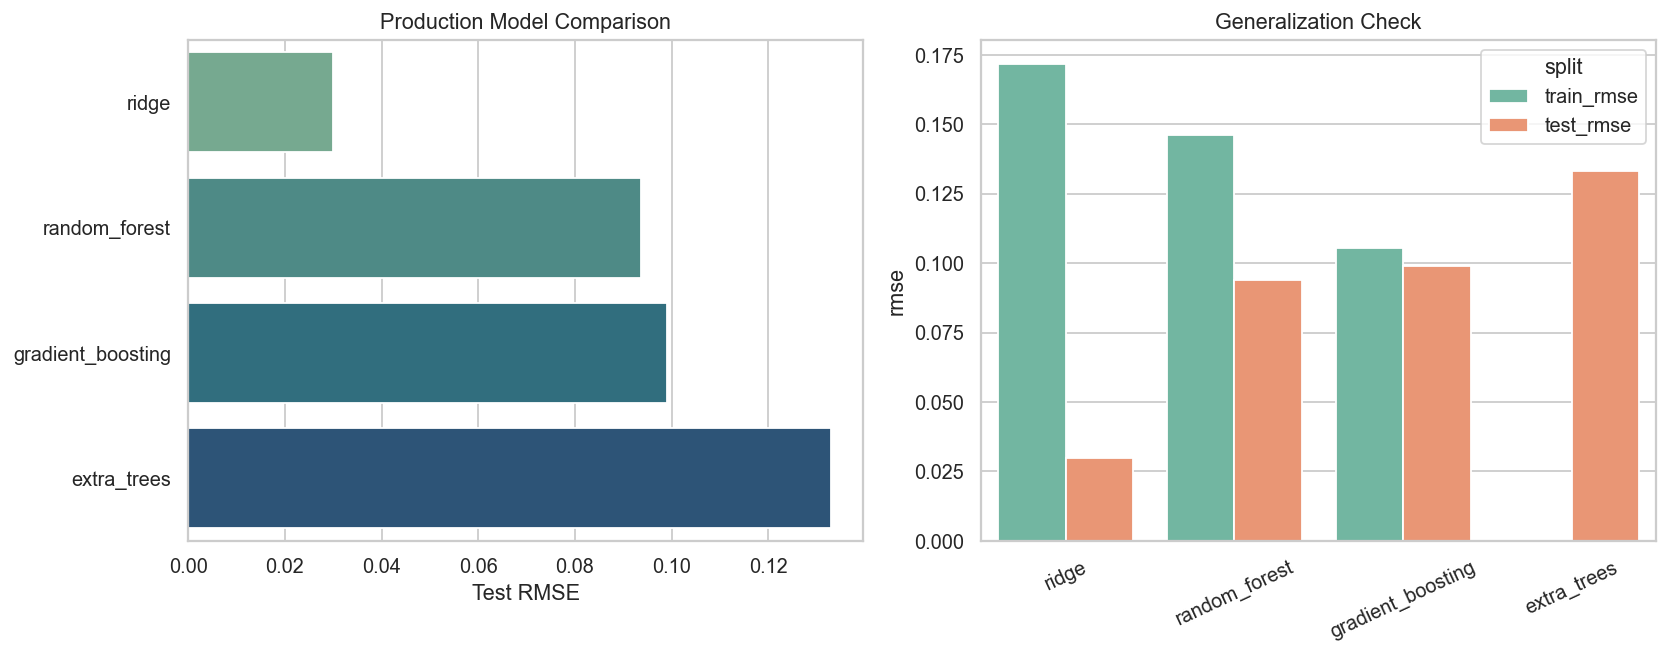

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

sns.barplot(
    data=results_df,
    x="test_rmse",
    y="model_name",
    hue="model_name",
    dodge=False,
    legend=False,
    ax=axes[0],
    palette="crest",
)
axes[0].set_title("Production Model Comparison")
axes[0].set_xlabel("Test RMSE")
axes[0].set_ylabel("")

long_df = results_df.melt(
    id_vars="model_name",
    value_vars=["train_rmse", "test_rmse"],
    var_name="split",
    value_name="rmse",
)
sns.barplot(data=long_df, x="model_name", y="rmse", hue="split", ax=axes[1], palette="Set2")
axes[1].set_title("Generalization Check")
axes[1].tick_params(axis="x", rotation=25)
axes[1].set_xlabel("")

fig.tight_layout()
fig.savefig(ASSET_DIR / "05_production_model_comparison.png", bbox_inches="tight")
plt.show()


In [6]:
subprocess.run([sys.executable, "dvc_pipeline/src/research_experiments.py"], check=True)


CompletedProcess(args=['c:\\aditi\\.venv\\Scripts\\python.exe', 'dvc_pipeline/src/research_experiments.py'], returncode=0)

In [7]:
research_cfg = params["research_experiments"]
research_results = pd.read_csv(research_cfg["results_path"]).sort_values("rmse").reset_index(drop=True)
research_summary = read_json(research_cfg["summary_path"])
research_predictions = pd.read_csv(research_cfg["predictions_path"])
arima_lstm_history = read_json(research_cfg["arima_lstm"]["history_path"])
history_df = pd.DataFrame(arima_lstm_history["history"])

research_results, research_summary, history_df.tail()

(                       model_name      rmse       mae      mape        r2  \
 0               hybrid_arima_lstm  1.857620  0.881063  0.007950  0.975986   
 1                    holt_winters  1.860330  0.871510  0.007880  0.975916   
 2                           arima  1.862345  0.879330  0.007951  0.975864   
 3  hybrid_arima_gradient_boosting  1.883381  0.906168  0.008193  0.975315   
 4                         svr_rbf  1.908242  0.960799  0.008683  0.974659   
 5               gradient_boosting  1.993823  1.083741  0.009776  0.972335   
 6                   random_forest  2.280127  1.469128  0.013048  0.963820   
 
    rmse_high_volatility  rmse_low_volatility  rolling_rmse_mean  \
 0              3.181722             1.325784           1.783984   
 1              3.192020             1.324267           1.783558   
 2              3.189553             1.329315           1.786301   
 3              3.179221             1.372066           1.816010   
 4              3.195388          

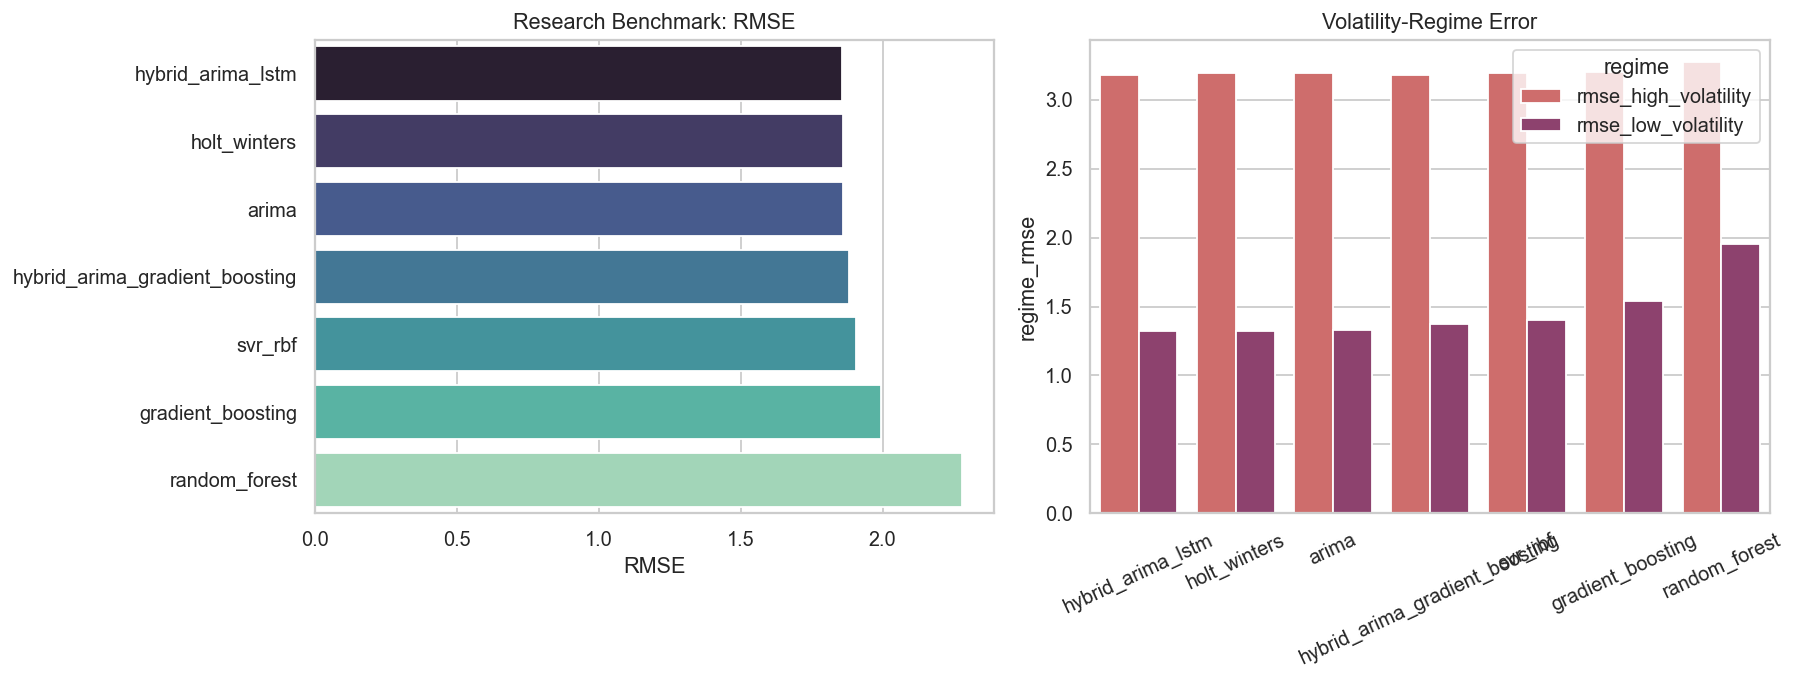

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))

sns.barplot(
    data=research_results,
    x="rmse",
    y="model_name",
    hue="model_name",
    dodge=False,
    legend=False,
    ax=axes[0],
    palette="mako",
)
axes[0].set_title("Research Benchmark: RMSE")
axes[0].set_xlabel("RMSE")
axes[0].set_ylabel("")

regime_df = research_results.melt(
    id_vars="model_name",
    value_vars=["rmse_high_volatility", "rmse_low_volatility"],
    var_name="regime",
    value_name="regime_rmse",
)
sns.barplot(data=regime_df, x="model_name", y="regime_rmse", hue="regime", ax=axes[1], palette="flare")
axes[1].set_title("Volatility-Regime Error")
axes[1].tick_params(axis="x", rotation=25)
axes[1].set_xlabel("")

fig.tight_layout()
fig.savefig(ASSET_DIR / "06_research_benchmark.png", bbox_inches="tight")
plt.show()


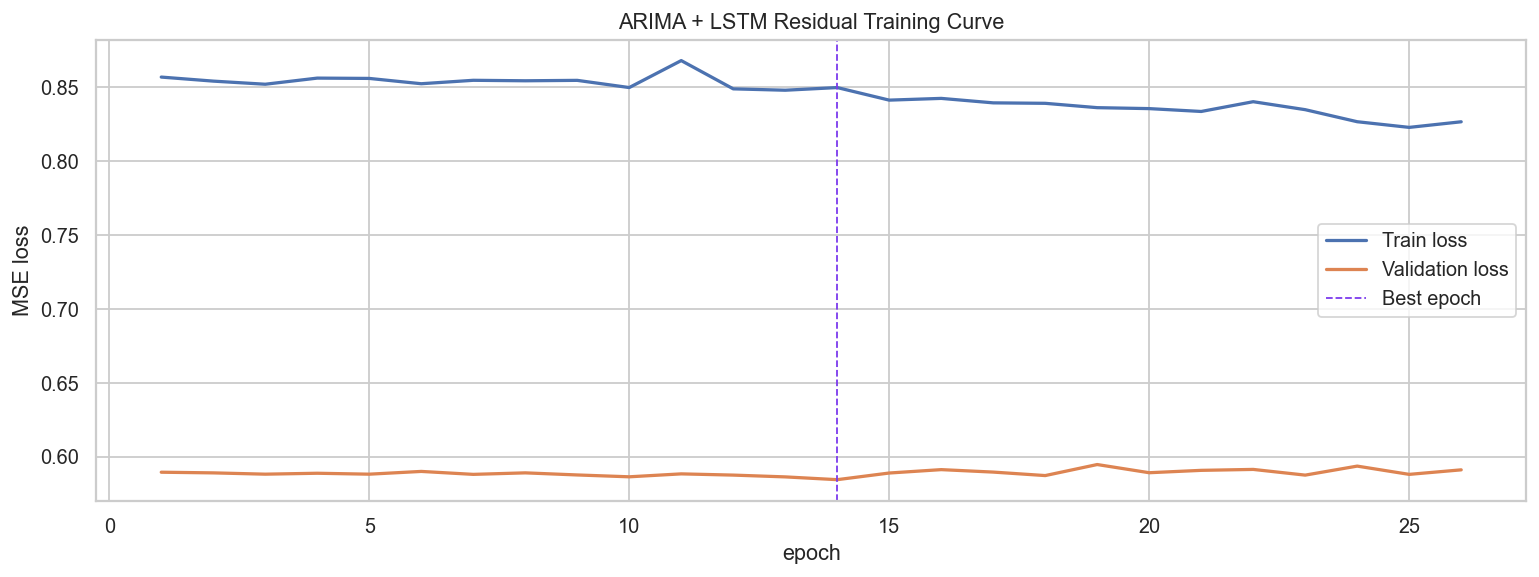

In [9]:
fig, ax = plt.subplots(figsize=(12, 4.6))

sns.lineplot(data=history_df, x="epoch", y="train_loss", ax=ax, label="Train loss", linewidth=1.8)
sns.lineplot(data=history_df, x="epoch", y="val_loss", ax=ax, label="Validation loss", linewidth=1.8)
ax.axvline(arima_lstm_history["best_epoch"], color="#7c3aed", linestyle="--", linewidth=1.0, label="Best epoch")
ax.set_title("ARIMA + LSTM Residual Training Curve")
ax.set_ylabel("MSE loss")
ax.legend()

fig.tight_layout()
fig.savefig(ASSET_DIR / "14_arima_lstm_history.png", bbox_inches="tight")
plt.show()

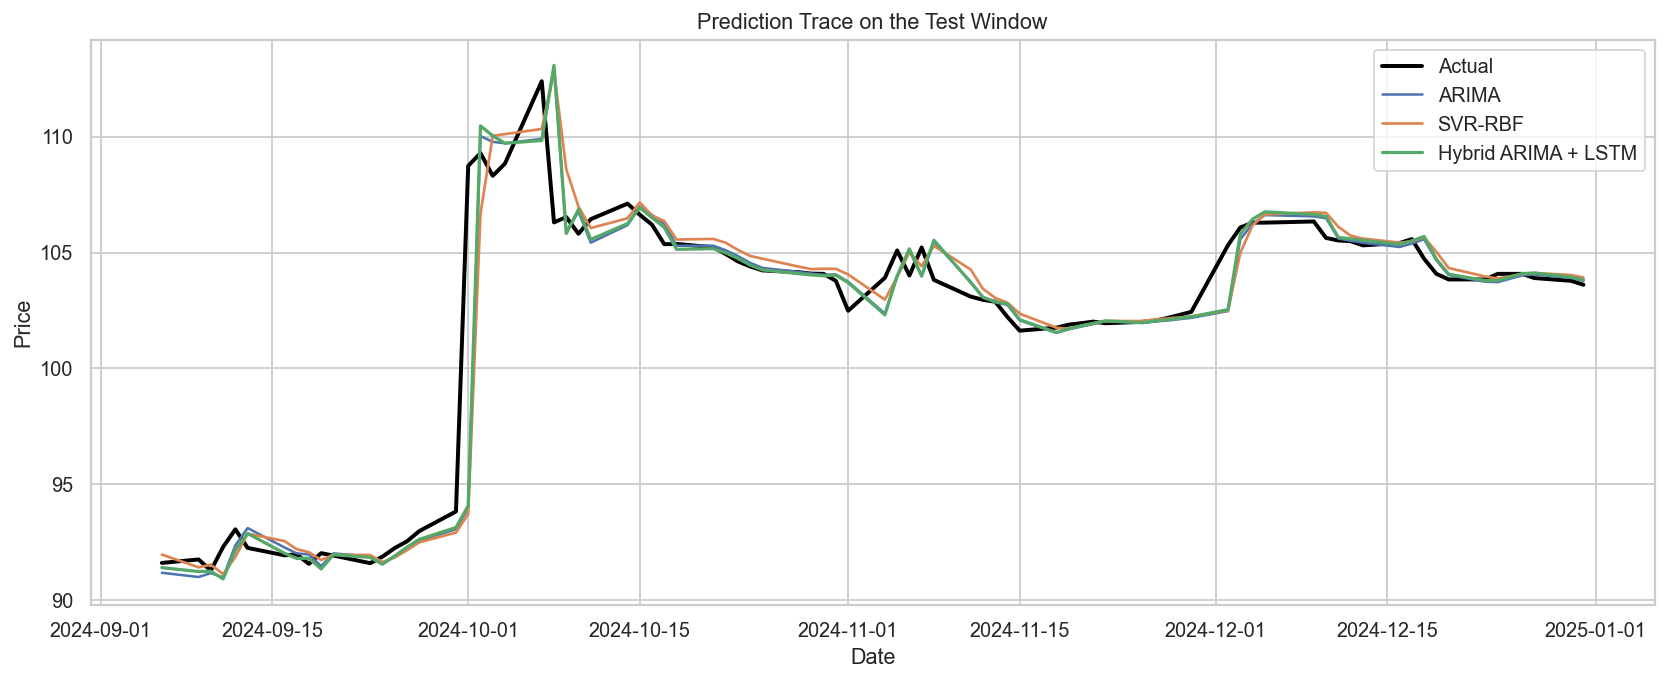

In [10]:
trace_df = research_predictions.copy()
trace_df["Date"] = pd.to_datetime(trace_df["Date"])
trace_df = trace_df.tail(80)

fig, ax = plt.subplots(figsize=(13, 5.4))
sns.lineplot(data=trace_df, x="Date", y="actual", ax=ax, label="Actual", linewidth=2.2, color="black")
sns.lineplot(data=trace_df, x="Date", y="pred_arima", ax=ax, label="ARIMA", linewidth=1.4)
sns.lineplot(data=trace_df, x="Date", y="pred_svr_rbf", ax=ax, label="SVR-RBF", linewidth=1.5)
sns.lineplot(
    data=trace_df,
    x="Date",
    y="pred_hybrid_arima_lstm",
    ax=ax,
    label="Hybrid ARIMA + LSTM",
    linewidth=1.8,
)
ax.set_title("Prediction Trace on the Test Window")
ax.set_ylabel("Price")

fig.tight_layout()
fig.savefig(ASSET_DIR / "07_research_prediction_traces.png", bbox_inches="tight")
plt.show()